# Experiment No. 4

## Aim
To implement K-Nearest Neighbors (KNN) and Decision Tree classifiers on the Iris dataset, and evaluate their performance using accuracy score and confusion matrix.

## Background

### K-Nearest Neighbors (KNN)
KNN is a supervised machine learning classification algorithm. It classifies a new data point based on the majority class among its K nearest neighbors.

### Decision Tree
A Decision Tree is a supervised learning algorithm that creates a tree-like structure by repeatedly splitting the dataset based on feature values. The splitting can be performed using criteria such as Gini impurity or entropy.

### Confusion Matrix
A confusion matrix is used to evaluate the performance of a classification model. It shows the number of correct and incorrect predictions for each class.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 1: Load the Iris Dataset

The Iris dataset is a built-in dataset available in `sklearn.datasets`.

It contains three classes:
- Setosa
- Versicolor
- Virginica

## Load the iris Dataset

In [3]:
iris = load_iris()

x = iris.data
y = iris.target

print("Feature Names: ")
print("iris.feature_names")

print("\nTarget Names: ")
print(iris.target_names)

print("\nDataset Shape: ")
print(x.shape)

Feature Names: 
iris.feature_names

Target Names: 
['setosa' 'versicolor' 'virginica']

Dataset Shape: 
(150, 4)


## Display the dataset

In [4]:
df = pd.DataFrame(x, columns=iris.feature_names)

df["target"] = y

df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Display dataset information
print("\nDataset Information:")
df.info()

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## Step 2: Split the Dataset

The dataset is divided into:
- Training data: 80%
- Testing data: 20%

The training data is used to train the models, while the testing data is used to evaluate their performance.

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print("Training Samples: ", x_train.shape[0])
print("Testing Samples: ", x_test.shape[0])

Training Samples:  120
Testing Samples:  30


## Step 3: Implement K-Nearest Neighbors (KNN)

The KNN classifier is created with K = 5.

The model finds the five nearest training samples for each test sample and assigns the class based on majority voting.

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy: ", knn_accuracy)
print("KNN Accuracy (%): ", knn_accuracy*100)

KNN Accuracy:  1.0
KNN Accuracy (%):  100.0


## Step 4: Confusion Matrix for KNN

In [8]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

KNN Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


## Visualize KNN confusion matrix

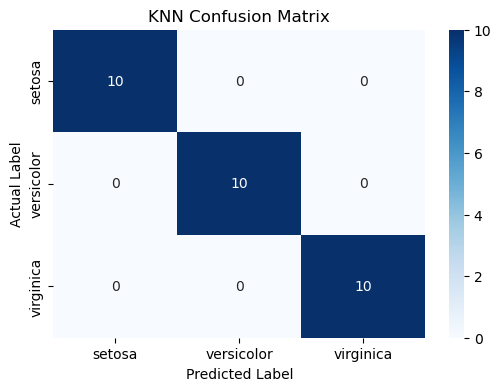

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_knn,
    annot = True,
    fmt="d",
    cmap="Blues",
    xticklabels = iris.target_names,
    yticklabels = iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("KNN Confusion Matrix")
plt.show()

In [11]:
print("KNN Classification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=iris.target_names
))

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 5: Implement Decision Tree

A Decision Tree classifier is created using the Gini impurity criterion.

The model learns decision rules from the training data and uses these rules to classify the test data.

In [12]:
# Create Decision Tree classifier
dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Train the Decision Tree
dt.fit(x_train, y_train)

# Make predictions
y_pred_dt = dt.predict(x_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", dt_accuracy * 100)

Decision Tree Accuracy: 0.9333333333333333
Decision Tree Accuracy (%): 93.33333333333333


## Step 6: Confusion Matrix for Decision Tree

In [13]:
# Calculate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


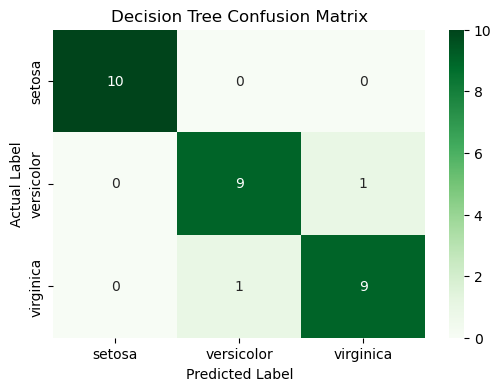

In [14]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [15]:
print("Decision Tree Classification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=iris.target_names
))

Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



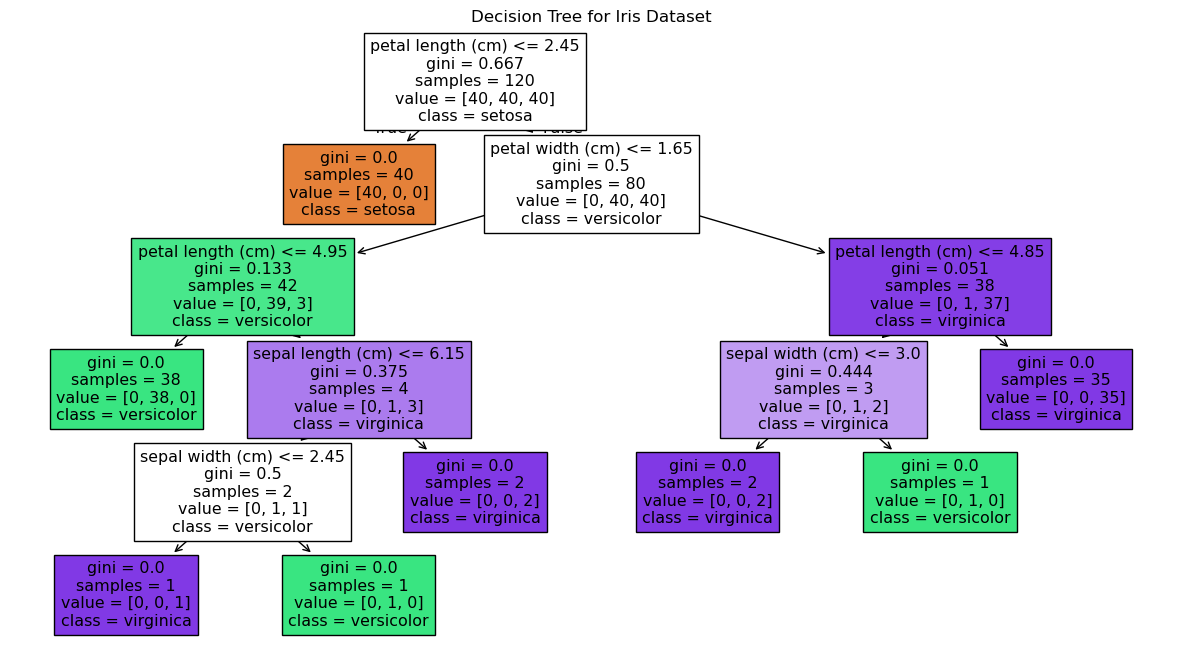

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree for Iris Dataset")
plt.show()

## Step 7: Compare KNN and Decision Tree

The accuracy of both classifiers is compared to determine their performance on the Iris dataset.

In [17]:
# Compare model accuracies
results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree"],
    "Accuracy": [knn_accuracy, dt_accuracy]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

print(results)

           Model  Accuracy  Accuracy (%)
0            KNN  1.000000    100.000000
1  Decision Tree  0.933333     93.333333


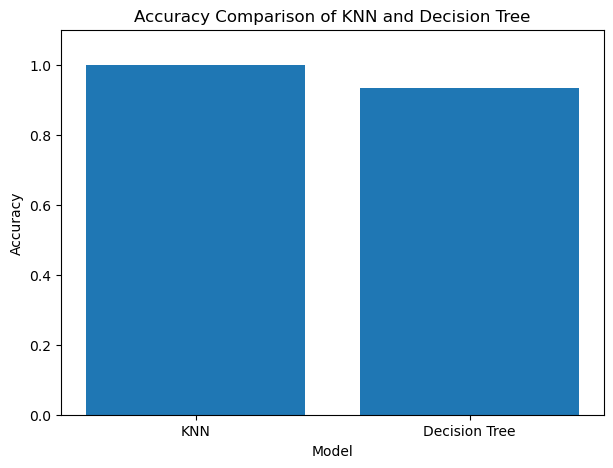

In [18]:
plt.figure(figsize=(7, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of KNN and Decision Tree")
plt.ylim(0, 1.1)

plt.show()

## Results

The K-Nearest Neighbors (KNN) and Decision Tree classifiers were successfully implemented on the Iris dataset.

The performance of both classifiers was evaluated using:
1. Accuracy Score
2. Confusion Matrix
3. Classification Report

The confusion matrices were also visualized using heatmaps.

The accuracy values obtained from the two models can be compared to determine which classifier performed better on the test dataset.

## Conclusion

K-Nearest Neighbors and Decision Tree classification algorithms were successfully implemented using the Iris dataset. The models were trained using the training data and evaluated using the testing data. Accuracy score and confusion matrix were used to measure the performance of both classifiers.

Both models provide good classification performance on the Iris dataset. The model with the higher test accuracy can be considered the better-performing classifier for this particular train-test split.